Name: Navpreet Kloy

Monday Lab Partner: Oscar Ramos

Wednesday Lab Partner: Oscar Ramos


Predict Students' Dropout and Academic Success: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [ ]:
# load dataset
df = pd.read_csv("data.csv",sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# data info overview
df.info()

# number of total samples and features
print('\nDataset shape (samples, features):', df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [ ]:
# view value counts for each unique value for each column
for col in df.columns:
    print('\n', df[col].value_counts())


 Marital status
1    3919
2     379
4      91
5      25
6       6
3       4
Name: count, dtype: int64

 Application mode
1     1708
17     872
39     785
43     312
44     213
7      139
18     124
42      77
51      59
16      38
53      35
15      30
5       16
10      10
2        3
57       1
26       1
27       1
Name: count, dtype: int64

 Application order
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
0       1
Name: count, dtype: int64

 Course
9500    766
9147    380
9238    355
9085    337
9773    331
9670    268
9991    268
9254    252
9070    226
171     215
8014    215
9003    210
9853    192
9119    170
9130    141
9556     86
33       12
Name: count, dtype: int64

 Daytime/evening attendance\t
1    3941
0     483
Name: count, dtype: int64

 Previous qualification
1     3717
39     219
19     162
3      126
12      45
40      40
42      36
2       23
6       16
9       11
4        8
38       7
43       6
10       4
15       2
5        1
14       1


In [ ]:
# view target distrubtion
print(df['Target'].value_counts())

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [ ]:
# Select features and label
X = df.drop(['Target'], axis=1)  # select feature columns
y = df['Target']         # label column

In [ ]:
# Split the data into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Scale features using StandardScaler
scaler = StandardScaler()                      # Instance of standard scaler
X_train_scaled= scaler.fit_transform(X_train)  # Learn scaling from training data
X_test_scaled = scaler.transform(X_test)        # Apply same scaling to test data

In [ ]:
# One-vs-Rest (OvA) Method

# record the current time to measure training duration
start_time = time.time()

# create OvA model using SVM with RBF kernel
model_ovr = OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))

# train the SVM model
model_ovr.fit(X_train_scaled, y_train)

# calculate total training time by subtracting start time from current time
train_time_ovr = time.time() - start_time

# make predictions on the test data
y_pred_ovr = model_ovr.predict(X_test_scaled)

# calculate the accuracy of model
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)

# print results including model stats and performance metrics
print(f"\nResults:")
print(f"  Training time: {train_time_ovr:.4f} seconds")
print(f"  Accuracy: {accuracy_ovr * 100:.2f}%")
print(f"  Number of classifiers trained: {len(model_ovr.estimators_)}")            # number of classifiers in OvA (𝑛 classifiers = 𝑛 classes)
print('\n Classification Report:\n ', classification_report(y_test, y_pred_ovr))   # report of classification metrics


Results:
  Training time: 1.5067 seconds
  Accuracy: 74.24%
  Number of classifiers trained: 3

 Classification Report:
                precision    recall  f1-score   support

     Dropout       0.77      0.78      0.77       284
    Enrolled       0.46      0.10      0.16       159
    Graduate       0.75      0.95      0.84       442

    accuracy                           0.74       885
   macro avg       0.66      0.61      0.59       885
weighted avg       0.70      0.74      0.70       885



In [ ]:
# One-vs-One (OvO) Method

# record the current time to measure model duration
start_time = time.time()

# create OvO SVM classifier with RBF kernel
model_ovo = OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))

# train the SVM model
model_ovo.fit(X_train_scaled, y_train)

# calculate total training time
train_time_ovo = time.time() - start_time

# make predictions on the test data
y_pred_ovo = model_ovo.predict(X_test_scaled)

# calculate the accuracy of model
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)

# print results including model stats and performance metrics
print(f"\nResults:")
print(f"  Training time: {train_time_ovo:.4f} seconds")
print(f"  Accuracy: {accuracy_ovo * 100:.2f}%")
print(f"  Number of classifiers trained: {len(model_ovo.estimators_)}")           # number of classifiers in OvO (uses binary classifiers - one per class pair)
print('\n Classification Report:\n ', classification_report(y_test, y_pred_ovo))



Results:
  Training time: 0.4868 seconds
  Accuracy: 75.59%
  Number of classifiers trained: 3

 Classification Report:
                precision    recall  f1-score   support

     Dropout       0.85      0.72      0.78       284
    Enrolled       0.49      0.35      0.41       159
    Graduate       0.77      0.93      0.84       442

    accuracy                           0.76       885
   macro avg       0.70      0.67      0.68       885
weighted avg       0.75      0.76      0.74       885



In [ ]:
# Compare OvO and OvA model perfomance
print(f"\n{'Strategy':<20} {'Accuracy':<12} {'Training Time':<15} {'# Classifiers'}")   # print results header
print(f"{'One-vs-Rest (OvA)':<20} {accuracy_ovr*100:>6.2f}%     {train_time_ovr:>8.4f}s      {len(model_ovr.estimators_)}")   # display results for OvA
print(f"{'One-vs-One (OvO)':<20} {accuracy_ovo*100:>6.2f}%     {train_time_ovo:>8.4f}s      {len(model_ovo.estimators_)}")    # display results for OvO

# store model accuracies in a dictionary for comparison
accuracies = {
    'One-vs-Rest (OvA)': accuracy_ovr,
    'One-vs-One (OvO)': accuracy_ovo
}

# determine best strategy with highest accuracy
best_strategy = max(accuracies, key=accuracies.get)

# print model defined as best strategy
print(f"\nBest accuracy: {best_strategy}")


Strategy             Accuracy     Training Time   # Classifiers
One-vs-Rest (OvA)     74.24%       1.5067s      3
One-vs-One (OvO)      75.59%       0.4868s      3

Best accuracy: One-vs-One (OvO)


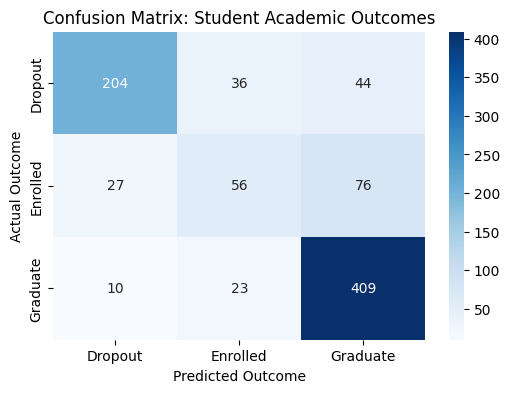

In [ ]:
# Confusion matrix for OvO strategy -- see how student outcomes are being predicted vs actual
cm = confusion_matrix(y_test, y_pred_ovo)

# define class labels for plot
labels = sorted(y.unique())

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels= labels, yticklabels=labels)
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')
plt.title('Confusion Matrix: Student Academic Outcomes')
plt.show()




2D Decision Boundary Visualization


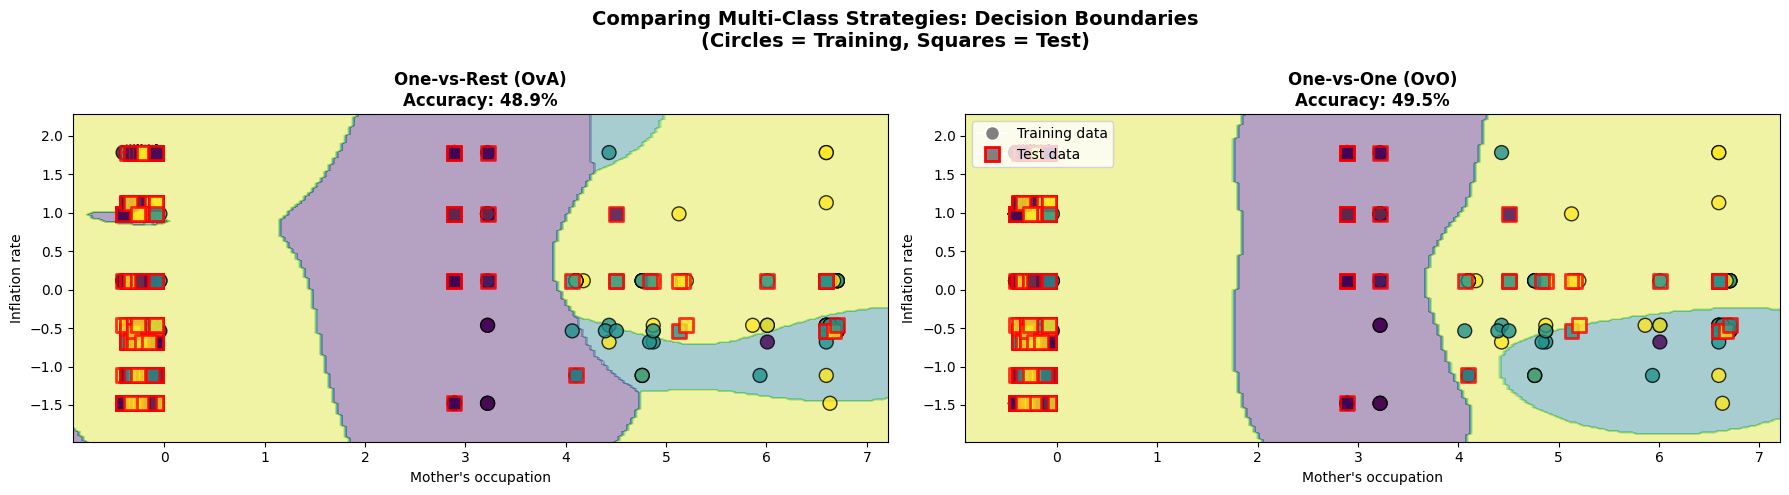

In [ ]:
# Visualize the decision boundary for 2 selected features

print("\n2D Decision Boundary Visualization")

# Select 2 features only for 2D visualization
X_2d = df[["Mother's occupation", 'Inflation rate']]  # Select 2 features only
y_mapped = y.map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})  # map y to enable decision boundary visualization

# split X_2d data into (30%) testing and training (80%) sets
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_mapped, test_size=0.3, random_state=42
)

# Scale the 2D data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# define SVM models
models_2d = {
    'One-vs-Rest (OvA)': OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0)),
    'One-vs-One (OvO)': OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
}

# Create a figure with 2 subplots and define figsize
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Create mesh grid for plotting decision boundaries
x_min, x_max = X_train_2d_scaled[:, 0].min() - 0.5, X_train_2d_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_2d_scaled[:, 1].min() - 0.5, X_train_2d_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))


# Train and plot each model
for idx, (name, model) in enumerate(models_2d.items()):
    # train model
    model.fit(X_train_2d_scaled, y_train_2d)
    # make preidcition on scaled 2d testing data
    y_pred_2d = model.predict(X_test_2d_scaled)

    # calculate the accuracy of 2d model
    acc_2d = accuracy_score(y_test_2d, y_pred_2d)

    # Predict class for every point in the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision regions
    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap='viridis')

    # Plot the training data points
    scatter = axes[idx].scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1],
                               c=y_train_2d, edgecolors='k',
                               cmap='viridis', s=100, alpha=0.8)

    # Plot the testing data points
    axes[idx].scatter(X_test_2d_scaled[:, 0], X_test_2d_scaled[:, 1],
                     c=y_test_2d, edgecolors='red', linewidths=2,
                     cmap='viridis', s=100, alpha=0.8, marker='s')

    # Add title and labels
    axes[idx].set_xlabel(X_2d.columns[0], fontsize=10)
    axes[idx].set_ylabel(X_2d.columns[1], fontsize=10)
    axes[idx].set_title(f'{name}\nAccuracy: {acc_2d*100:.1f}%',
                       fontsize=12, fontweight='bold')

# add legened
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=10, label='Training data'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
           markeredgecolor='red', markeredgewidth=2, markersize=10, label='Test data')
]
axes[1].legend(handles=legend_elements, loc='upper left')

# set overall title
plt.suptitle('Comparing Multi-Class Strategies: Decision Boundaries\n(Circles = Training, Squares = Test)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


The Predict Students' Dropout and Academic Success dataset was used to build a model to predict student’s academic outcomes from higher education that were in various undergraduate programs. There were 3 possible outcomes: Graduate, Dropout, and Enrolled. The data contained a total of 4,424 data points and 37 features. The features included demographic indicators, students' academic performance information from 2 semesters, school related statistics, and economic indicators such as GDP and inflation rate. All features excluding the target variable were used as predictors to build the models. After data processing and model training and prediction on both the strategies, it was found OvO strategy had the best model based on its higher accuracy (75.59% ). The individual class performance metrics varied across the 3 possible outcomes. The model did better in identifying dropouts and graduates, compared to enrolled. The model is most likely to miss identifying enrolled cases, while actual dropout cases, least to miss graduate outcomes (93% recall). However, the enrolled outcome had higher false positives (49% precision), and was more likely to fail to be identified in general (35% recall). The confusion matrix also shows a similar pattern, the actual enrolled cases are spread out across two other outcomes, meaning it had a high chance of falsely being predicted as other two classes. A sample visualization on two selected features shows how both models define the class regions. The two selected features were processed and both the models were trained, then points and decision boundaries were plotted and defined. The general performance of classes had a F1-score of 0.74, which is not too low, however a closer look reveals an imbalance in class performance. Overall, the model has a decent performance in identifying student academic outcomes, but is significantly weaker with the enrolled outcome.
